# Coles Group – Customer Analytics Case Study
### End-to-end reproducible pipeline: Random Forest + SVM on two datasets

Run every cell top to bottom (Runtime → Run all in Colab). This reproduces every number and figure used in Section 3 (Data Analysis) of the report.

**Datasets used:**
- UCI Online Retail
- Customer Personality Analysis

## 1. Setup

In [1]:
import subprocess, sys

def pip_install(pkg):
    for extra_args in ([], ["--user"], ["--break-system-packages"]):
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", *extra_args, pkg],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            return
    print(f"Warning: could not auto-install {pkg}; install it manually if import fails below.")

for pkg in ["pandas", "numpy", "scikit-learn", "matplotlib", "openpyxl"]:
    pip_install(pkg)

import os, json, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc,
)

RANDOM_STATE = 42

## 2. Download datasets

In [2]:
RETAIL_URL = ("https://raw.githubusercontent.com/eaintkyawthmu/"
              "UCI_Online_Retail_Dataset_Cleaned_Version/master/"
              "Online%20Retail.xlsx")
CPA_URL = ("https://raw.githubusercontent.com/AbirLassoued/"
           "CUSTOMER_PERSONALITY_ANALYSIS/main/marketing_campaign.csv")

if not os.path.exists("OnlineRetail.xlsx"):
    urllib.request.urlretrieve(RETAIL_URL, "OnlineRetail.xlsx")
print("OnlineRetail.xlsx:", os.path.getsize("OnlineRetail.xlsx"), "bytes")

if not os.path.exists("marketing_campaign.csv"):
    urllib.request.urlretrieve(CPA_URL, "marketing_campaign.csv")
print("marketing_campaign.csv:", os.path.getsize("marketing_campaign.csv"), "bytes")

OnlineRetail.xlsx: 23715344 bytes
marketing_campaign.csv: 220188 bytes


## 3. Clean Dataset 1: Online Retail → RFM features
Removes cancelled orders, missing customer IDs, and non-positive quantity/price. Aggregates to customer-level Recency/Frequency/Monetary features and engineers an `Engaged_Customer` proxy label (this dataset has no explicit campaign-response field).

In [3]:
df = pd.read_excel("OnlineRetail.xlsx")
print("Raw shape:", df.shape)

df = df.dropna(subset=["CustomerID"])
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["CustomerID"] = df["CustomerID"].astype(int)
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
print("Cleaned shape:", df.shape, "| Unique customers:", df["CustomerID"].nunique())

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    AvgBasketValue=("TotalPrice", "mean"),
    UniqueProducts=("StockCode", "nunique"),
    TotalItems=("Quantity", "sum"),
).reset_index()

top_country = df.groupby("CustomerID")["Country"].agg(lambda x: x.mode().iloc[0])
rfm = rfm.merge(top_country.rename("Country"), on="CustomerID")
rfm["IsUK"] = (rfm["Country"] == "United Kingdom").astype(int)

freq_median = rfm["Frequency"].median()
mon_median = rfm["Monetary"].median()
rfm["Engaged_Customer"] = (
    (rfm["Frequency"] >= freq_median) & (rfm["Monetary"] >= mon_median)
).astype(int)

print("Engaged_Customer balance:")
print(rfm["Engaged_Customer"].value_counts(normalize=True))
rfm.head()

Raw shape: (541909, 8)


Cleaned shape: (397884, 9) | Unique customers: 4338


Engaged_Customer balance:
Engaged_Customer
0    0.533656
1    0.466344
Name: proportion, dtype: float64


,CustomerID,Recency,Frequency,Monetary,AvgBasketValue,UniqueProducts,TotalItems,Country,IsUK,Engaged_Customer
0,12346,326,1,77183.60,77183.600000,1,74215,United Kingdom,1,0
1,12347,2,7,4310.00,23.681319,103,2458,Iceland,0,1
2,12348,75,4,1797.24,57.975484,22,2341,Finland,0,1
3,12349,19,1,1757.55,24.076027,73,631,Italy,0,0
4,12350,310,1,334.40,19.670588,17,197,Norway,0,0


## 4. Clean Dataset 2: Customer Personality Analysis
Removes missing income and implausible birth years. Engineers `Total_Spend`, `Total_Purchases`, `Total_PriorCampaignsAccepted`, `Customer_Tenure_Days` and `Children`. Target is the existing `Response` field.

In [4]:
cpa = pd.read_csv("marketing_campaign.csv", sep="\t")
print("Raw shape:", cpa.shape)

cpa = cpa.dropna(subset=["Income"])
cpa = cpa[cpa["Income"] < 200000]
cpa = cpa[cpa["Year_Birth"] > 1930]

cpa["Age"] = 2014 - cpa["Year_Birth"]
cpa["Dt_Customer"] = pd.to_datetime(cpa["Dt_Customer"], format="%d-%m-%Y")
cpa["Customer_Tenure_Days"] = (cpa["Dt_Customer"].max() - cpa["Dt_Customer"]).dt.days

mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
            "MntSweetProducts", "MntGoldProds"]
cpa["Total_Spend"] = cpa[mnt_cols].sum(axis=1)

purchase_cols = ["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
cpa["Total_Purchases"] = cpa[purchase_cols].sum(axis=1)

cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]
cpa["Total_PriorCampaignsAccepted"] = cpa[cmp_cols].sum(axis=1)

cpa["Children"] = cpa["Kidhome"] + cpa["Teenhome"]
cpa["Marital_Status"] = cpa["Marital_Status"].replace(
    {"Alone": "Single", "YOLO": "Single", "Absurd": "Single"}
)

cpa = cpa.drop(columns=["ID", "Year_Birth", "Dt_Customer", "Z_CostContact", "Z_Revenue"])
print("Cleaned shape:", cpa.shape)
print("Response balance:")
print(cpa["Response"].value_counts(normalize=True))
cpa.head()

Raw shape: (2240, 29)
Cleaned shape: (2212, 30)
Response balance:
Response
0    0.849458
1    0.150542
Name: proportion, dtype: float64


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Tenure_Days,Total_Spend,Total_Purchases,Total_PriorCampaignsAccepted,Children
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,0,0,0,1,57,663,1617,25,0,0
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,60,113,27,6,0,2
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,49,312,776,21,0,0
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,30,139,53,8,0,1
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,33,161,422,19,0,1


## 5. Train Random Forest + SVM
Trained separately on each dataset (75/25 stratified split, standardised/one-hot-encoded features, balanced class weights). Note: `Frequency`/`Monetary` are excluded from Dataset 1's predictors since they were used to define the `Engaged_Customer` label (avoids leakage).

In [5]:
RESULTS = {}

def run_pipeline(name, X, y, cat_cols, num_cols):
    print(f"\n{'-'*70}\n{name}\n{'-'*70}")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
    )
    preprocess = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])

    results, fitted = {}, {}

    rf = Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        class_weight="balanced", random_state=RANDOM_STATE))])
    rf.fit(X_train, y_train)
    y_pred, y_proba = rf.predict(X_test), rf.predict_proba(X_test)[:, 1]
    results["Random Forest"] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    fitted["Random Forest"] = rf

    svm = Pipeline([("prep", preprocess), ("clf", SVC(
        kernel="rbf", C=1.0, gamma="scale", probability=True,
        class_weight="balanced", random_state=RANDOM_STATE))])
    svm.fit(X_train, y_train)
    y_pred, y_proba = svm.predict(X_test), svm.predict_proba(X_test)[:, 1]
    results["SVM"] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    fitted["SVM"] = svm

    for m, r in results.items():
        print(f"{m}: " + ", ".join(f"{k}={v:.3f}" for k, v in r.items()))

    feat_names = num_cols + list(
        fitted["Random Forest"].named_steps["prep"]
        .named_transformers_["cat"].get_feature_names_out(cat_cols)
    )
    rf_imp = sorted(zip(feat_names, fitted["Random Forest"].named_steps["clf"].feature_importances_),
                     key=lambda x: -x[1])[:6]
    print("Top RF features:", [(f, round(float(v), 3)) for f, v in rf_imp])

    RESULTS[name] = {"metrics": results, "rf_top_features": rf_imp,
                      "n_train": len(X_train), "n_test": len(X_test)}
    return fitted, X_test, y_test


# Dataset 1
num_cols_r = ["Recency", "AvgBasketValue", "UniqueProducts", "TotalItems"]
Xr = rfm[num_cols_r + ["IsUK"]].copy()
Xr["IsUK"] = Xr["IsUK"].astype(str)
yr = rfm["Engaged_Customer"]
models_r, Xr_test, yr_test = run_pipeline(
    "Dataset 1: Online Retail (target = Engaged_Customer proxy)",
    Xr, yr, ["IsUK"], num_cols_r)

# Dataset 2
cat_cols_c = ["Education", "Marital_Status"]
num_cols_c = [c for c in cpa.columns if c not in cat_cols_c + ["Response"]]
Xc = cpa[num_cols_c + cat_cols_c].copy()
yc = cpa["Response"]
models_c, Xc_test, yc_test = run_pipeline(
    "Dataset 2: Customer Personality Analysis (target = Response)",
    Xc, yc, cat_cols_c, num_cols_c)


----------------------------------------------------------------------
Dataset 1: Online Retail (target = Engaged_Customer proxy)
----------------------------------------------------------------------


Random Forest: accuracy=0.922, precision=0.907, recall=0.927, f1=0.917, roc_auc=0.981
SVM: accuracy=0.882, precision=0.872, recall=0.875, f1=0.874, roc_auc=0.957
Top RF features: [('TotalItems', 0.514), ('UniqueProducts', 0.272), ('AvgBasketValue', 0.108), ('Recency', 0.104), ('IsUK_0', 0.001), ('IsUK_1', 0.001)]

----------------------------------------------------------------------
Dataset 2: Customer Personality Analysis (target = Response)
----------------------------------------------------------------------


Random Forest: accuracy=0.846, precision=0.487, recall=0.470, f1=0.479, roc_auc=0.868
SVM: accuracy=0.850, precision=0.500, recall=0.699, f1=0.583, roc_auc=0.890
Top RF features: [('Total_PriorCampaignsAccepted', 0.109), ('Customer_Tenure_Days', 0.107), ('Recency', 0.107), ('Total_Spend', 0.07), ('MntGoldProds', 0.058), ('MntWines', 0.052)]


## 6. Results table (Table 1 in the report)

In [6]:
rows = []
for dataset, res in RESULTS.items():
    short = "Online Retail" if "Online Retail" in dataset else "Cust. Personality"
    for model, m in res["metrics"].items():
        rows.append({"Dataset": short, "Model": model, **{k: round(v, 3) for k, v in m.items()}})

results_df = pd.DataFrame(rows)
results_df

,Dataset,Model,accuracy,precision,recall,f1,roc_auc
0,Online Retail,Random Forest,0.922,0.907,0.927,0.917,0.981
1,Online Retail,SVM,0.882,0.872,0.875,0.874,0.957
2,Cust. Personality,Random Forest,0.846,0.487,0.470,0.479,0.868
3,Cust. Personality,SVM,0.850,0.500,0.699,0.583,0.890


## 7. ROC curves

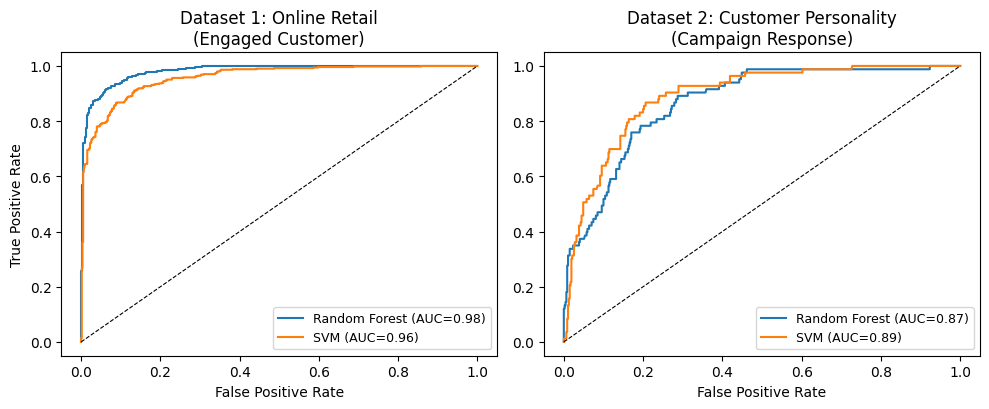

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (models, X_test, y_test, title) in zip(axes, [
    (models_r, Xr_test, yr_test, "Dataset 1: Online Retail\n(Engaged Customer)"),
    (models_c, Xc_test, yc_test, "Dataset 2: Customer Personality\n(Campaign Response)"),
]):
    for name, model in models.items():
        fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.legend(fontsize=9, loc="lower right")
axes[0].set_ylabel("True Positive Rate")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=200)
plt.show()

## 8. Feature importance (Random Forest)

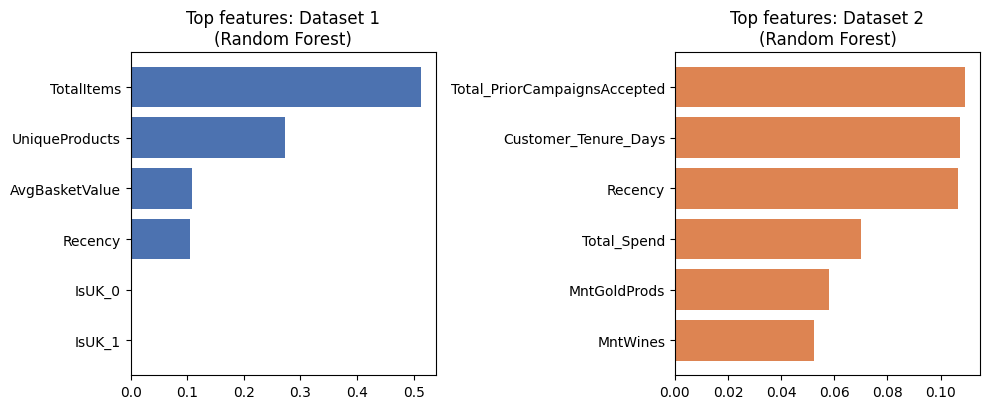

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, name, color in zip(axes, RESULTS, ["#4C72B0", "#DD8452"]):
    feats = RESULTS[name]["rf_top_features"]
    ax.barh([f[0] for f in feats][::-1], [float(f[1]) for f in feats][::-1], color=color)
    ax.set_title(f"Top features: {name.split(':')[0]}\n(Random Forest)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=200)
plt.show()

## 9. Save everything
Saves the cleaned datasets, results JSON, and both figures to disk — download these from the Colab file browser (left sidebar) for your Process Documentation screenshots.

In [9]:
rfm.to_csv("retail_rfm_features.csv", index=False)
cpa.to_csv("cpa_features.csv", index=False)

results_json = {k: {"metrics": v["metrics"],
                     "rf_top_features": [(f, float(imp)) for f, imp in v["rf_top_features"]],
                     "n_train": v["n_train"], "n_test": v["n_test"]}
                 for k, v in RESULTS.items()}
with open("results_summary.json", "w") as f:
    json.dump(results_json, f, indent=2)

print("Saved: retail_rfm_features.csv, cpa_features.csv, results_summary.json,")
print("       roc_curves.png, feature_importance.png")

Saved: retail_rfm_features.csv, cpa_features.csv, results_summary.json,
       roc_curves.png, feature_importance.png
